In [ ]:
import numpy as np


In [19]:
import datetime as dt
import hashlib
import json
import logging
import os
import pickle
import pprint

# # Must run before pyplot so figures embed in the notebook (Cursor / VS Code / Jupyter).
# %matplotlib inline

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.path as mpltPath
from IPython.display import display
import numpy as np
import pandas as pd
import tqdm
from scipy import integrate, optimize
import scipy
from scipy.optimize import root_scalar
from scipy.integrate import quad
from shapely import wkb
from shapely.geometry import Point, Polygon, MultiPoint
from shapely.prepared import prep
from shapely.ops import voronoi_diagram, transform

from etas.inversion import ETASParameterCalculation, polygon_surface, upper_gamma_ext
from etas import mc_b_est

try:
    import pyproj
except ImportError:
    pyproj = None

pp = pprint.PrettyPrinter(indent=2, width=100, sort_dicts=True)


def print_params(title, **kwargs):
    """Lightweight substitute for utility_functions.log_etas_params (no file I/O)."""
    print(f"\n=== {title} ===")
    for key, value in kwargs.items():
        if isinstance(value, dict):
            print(f"  {key}:")
            pp.pprint(value)
        else:
            print(f"  {key}: {value!r}")


In [ ]:
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}


def time_sampling_func(
    t,
    c=np.power(10, THETA_0["log10_c"]),
    tau=np.power(10, THETA_0["log10_tau"]),
    omega=THETA_0["omega"],
):
  # return 1 - scipy.special.gammaincc(-omega, (dt+c)/tau) / scipy.special.gammaincc(-omega, c/tau)
  return (
      1
      - upper_gamma_ext(-omega, (t + c) / tau)
      / upper_gamma_ext(-omega, c / tau)
  )


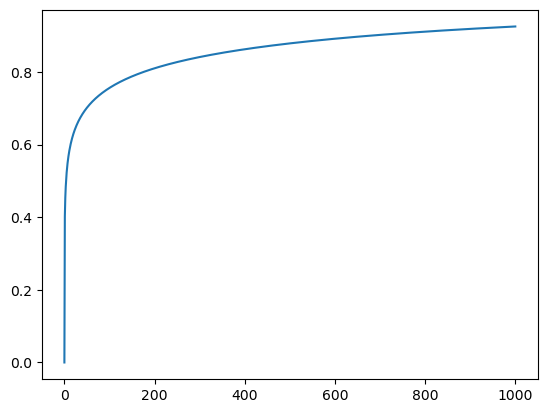

In [ ]:
dt_vec = np.linspace(0, 1000, 1000)
U = time_sampling_func(dt_vec)
plt.plot(dt_vec, U)
plt.show()


2026-06-04 17:35:32,162 - DEBUG - vmin 0.7087253787774066 vmax 1410.9823465360512
2026-06-04 17:35:32,163 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])
2026-06-04 17:35:32,166 - DEBUG - vmin 0.7087253787774066 vmax 1410.9823465360512
2026-06-04 17:35:32,167 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05])
2026-06-04 17:35:32,167 - DEBUG - vmin 0.7087253787774066 vmax 1410.9823465360512
2026-06-04 17:35:32,167 - D

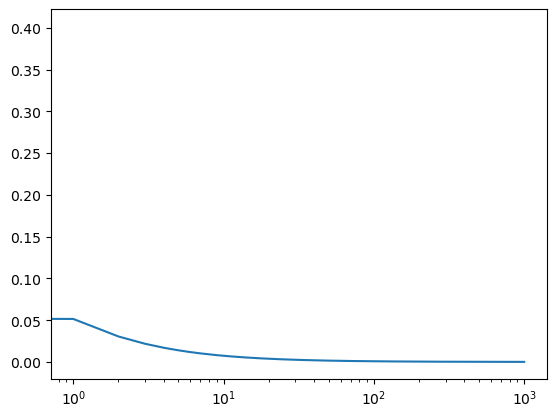

In [ ]:
U_diff = np.diff(U)
plt.plot(dt_vec[:-1], U_diff)
plt.xscale('log')
plt.show()
